# Fabry-Perot Optical Extraction Engine
**Architect:** Sapun Sunar

## 1. Abstract & The Arsenal
This notebook contains the mathematical and computational architecture required to extract absolute quantum physical metrics from a severely damaged optical sensor. We will process raw `.sif` camera data of a Cadmium emission source ($228.802 \text{ nm}$) passed through a Fabry-Perot etalon. 

The primary objective is to calculate the Free Spectral Range (FSR) by transforming a noisy 2D Cartesian image into a pristine 1D quantum spectrum. We initiate by importing our mathematical and visual matrices.

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.signal import find_peaks, savgol_filter
from sip_decoder import decoded_matrix
from center import calculate_box_center

# Data Ingestion Part.
## 2. Data Ingestion & Absolute Calibration
Standard center-of-mass algorithms fail when a sensor exhibits asymmetric damage or dead pixels. To circumvent this, we dictate a strict spatial quarantine. By isolating a pristine sub-section of the innermost interference ring, we force the algebraic matrix to calculate the sub-pixel optical axis (the true center of the geometry) completely immune to the surrounding void.

using the sip decoder the .sip file is decoded into a 2*2 matrix of pixels which contains the photons intensities. We then see the picture and draw our x_min, x_max, y_min and y_max which is a square boundary around the first ring of our fabry perot, the boundaries must make a square. Using matplotlib's visual and cropping tools, the boundaries are to be self-verified.
$$y_{max} - y_{min} = x_{max} - x_{min}$$

After getting the sqaure box, the center of the fabry perot is calculated using the cetner of the mass from our center.py.

In [74]:
# Data Ingestion.
image_matrix = decoded_matrix("/Users/sapunsunar/Documents/CODES/Lab data/cadmium absorption line sept 23 228.802nm 02.sif")

# Getting previously self-verified center calibration box.
x_min_box, x_max_box = 320, 445
y_min_box, y_max_box = 42, 167
y_center, x_center = calculate_box_center(image_matrix, x_min_box, x_max_box, y_min_box, y_max_box)

## 3. Inverse Mapping & The Boolean Pincer
We must unroll the 2D interference rings into a 1D array. To do this, we execute a coordinate transformation from Cartesian to Polar space for every pixel on the sensor:
$$r = \sqrt{(x - x_c)^2 + (y - y_c)^2}$$
$$\theta = \arctan \left( \frac{y - y_c}{x - x_c} \right)$$

To ensure absolute data purity, we deploy a "Boolean Pincer Mask." This isolates two distinct, undamaged angular wedges (Sector Alpha and Sector Bravo), extracting only valid photons and blinding the algorithm to the damaged zones.

In [75]:
# --- 2. INVERSE MAPPING & DUAL-SECTOR MASKING ---
y_indices, x_indices = np.indices(image_matrix.shape)
raw_angles = np.degrees(np.arctan2(y_indices - y_center, x_indices - x_center))


# NORMALIZATION: Force all angles into a clean 0 to 360 degree compass
angle_seg = np.mod(raw_angles, 360)
radii = np.sqrt((x_indices - x_center)**2 + (y_indices - y_center)**2)


# --- Define Sector Alpha ---
s1_min, s1_max = 130, 180
# --- Define Sector Bravo ---
s2_min, s2_max = 275, 330

radius_max = 85

# Apply the Boolean Pincer Mask (Using the Bitwise OR operator '|')
mask_alpha = (angle_seg >= s1_min) & (angle_seg <= s1_max)
mask_bravo = (angle_seg >= s2_min) & (angle_seg <= s2_max)
master_mask = (mask_alpha | mask_bravo) & (radii <= radius_max)

valid_radii = radii[master_mask]
valid_intensities = image_matrix[master_mask]

## 4. The Diagnostic HUD
Before processing the spectrum, we must visually verify the mathematical targeting. We construct a 2D rendering of the raw sensor data, overlaying our calculated optical axis and the exact boundaries of the integration sectors.

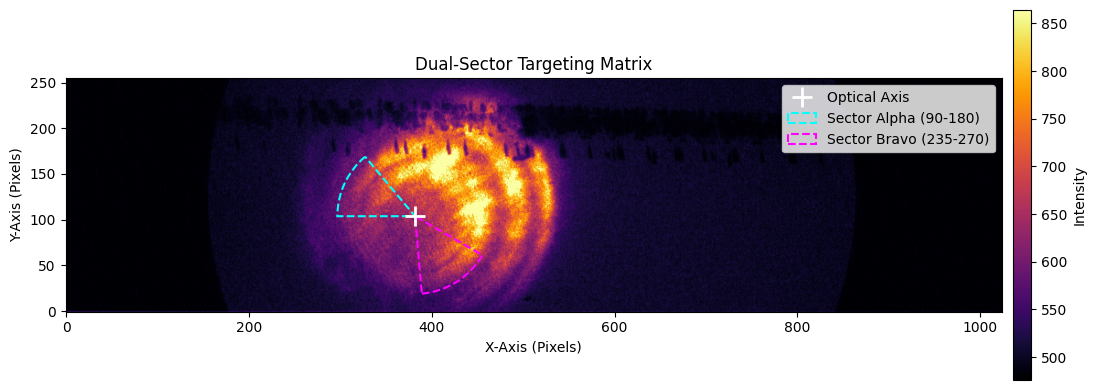

In [76]:
plt.figure(figsize=(12, 4))

vmin_val = np.percentile(image_matrix, 5)
vmax_val = np.percentile(image_matrix, 99.5)
plt.imshow(image_matrix, origin='lower', cmap='inferno', aspect='equal', vmin=vmin_val, vmax=vmax_val)

# Optical Center
plt.plot(x_center, y_center, 'w+', markersize=15, markeredgewidth=2, label='Optical Axis')

# Draw Sector Alpha (Cyan)
wedge_alpha = patches.Wedge((x_center, y_center), radius_max, s1_min, s1_max, 
                            fill=False, edgecolor='cyan', linestyle='--', linewidth=1.5, label='Sector Alpha (90-180)')
plt.gca().add_patch(wedge_alpha)

# Draw Sector Bravo (Magenta)
wedge_bravo = patches.Wedge((x_center, y_center), radius_max, s2_min, s2_max, 
                            fill=False, edgecolor='magenta', linestyle='--', linewidth=1.5, label='Sector Bravo (235-270)')
plt.gca().add_patch(wedge_bravo)

plt.colorbar(label='Intensity', pad=0.01)
plt.title("Dual-Sector Targeting Matrix")
plt.xlabel("X-Axis (Pixels)") 
plt.ylabel("Y-Axis (Pixels)")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 5. Sub-Pixel Interpolation Engine
A standard rounding algorithm destroys sub-pixel geometry by forcing fractional radii into single integer buckets. 

This engine utilizes **Linear Interpolation**. If a photon lands at a mathematical radius of $45.8$ pixels, the algorithm isolates the decimal and physically splits the photon's energy: $80\%$ of its weight spills forward into integer bucket 46, and $20\%$ leaks backward into bucket 45. This preserves the absolute curvature of the Cadmium absorption lines.

In [77]:
# --- 4. SUB-PIXEL INTERPOLATION ENGINE ---
print("Engaging Fractional Photon Splitting...")

# Extract the decimal to split the light
fractional_part = valid_radii % 1.0
weight_upper = fractional_part
weight_lower = 1.0 - fractional_part

# Define the adjacent integer buckets
bin_lower = np.floor(valid_radii).astype(int)
bin_upper = bin_lower + 1

# Split the intensity proportionally
intensity_lower = valid_intensities * weight_lower
intensity_upper = valid_intensities * weight_upper

max_bin = np.max(bin_upper) + 1

# Dual-Bincount to sum the split photons
radial_intensity = np.bincount(bin_lower, weights=intensity_lower, minlength=max_bin) + \
                   np.bincount(bin_upper, weights=intensity_upper, minlength=max_bin)

# Split the pixel counts using the same weights!
pixel_count = np.bincount(bin_lower, weights=weight_lower, minlength=max_bin) + \
              np.bincount(bin_upper, weights=weight_upper, minlength=max_bin)

pixel_count[pixel_count == 0] = 1 # Prevent universe implosion
spectrum_1d = radial_intensity / pixel_count


Engaging Fractional Photon Splitting...


## 6. Signal Processing & Peak Detection
With the 1D spectrum extracted, we deploy a Savitzky-Golay filter to iron out high-frequency thermal sensor static while preserving the depth of our quantum transitions. 

To prevent the `find_peaks` algorithm from falsely flagging the chaotic noise at near the singularity (radius 0), we deploy a "Half-Radius Blindfold," commanding the matrix to only search for absorption valleys and emission peaks in the stable outer regions of the geometry.

In [78]:
# --- 4. SIGNAL PROCESSING ---
# Iron out the high-frequency thermal noise
smoothed_spectrum = savgol_filter(spectrum_1d, window_length=15, polyorder=3)

# Calculate the exact midpoint of your current graph
search_start = len(smoothed_spectrum) // 2
detected_valleys, properties = find_peaks(-smoothed_spectrum[search_start:], prominence=10, distance=30)
detected_valleys = detected_valleys + search_start

valley_intensities = smoothed_spectrum[detected_valleys]
peak_distances = np.diff(detected_valleys)

# --- 5. TERMINAL HUD ---
print(f"Total Valleys Isolated: {len(detected_valleys)}")
for i in range(len(detected_valleys)):
    print(f"Absorption Line {i+1} locked at radius: {detected_valleys[i]} pixels")
    if i < len(detected_valleys) - 1:
        print(f"   -> Gap to next line (FSR): {peak_distances[i]} pixels")

# Distance Between Detected Lines.
peaks_corrected, information = find_peaks(smoothed_spectrum, prominence=10, distance=10)
distance_peaks = np.diff(peaks_corrected)
print(f"Absorption Line Distnace = {distance_peaks} pixels")

Total Valleys Isolated: 1
Absorption Line 1 locked at radius: 60 pixels
Absorption Line Distnace = [21] pixels


## 7. The Final Spectrum Render
We project the raw fractional data against the filtered Savitzky-Golay curve, plotting visual crosshairs precisely over the calculated quantum absorption states.

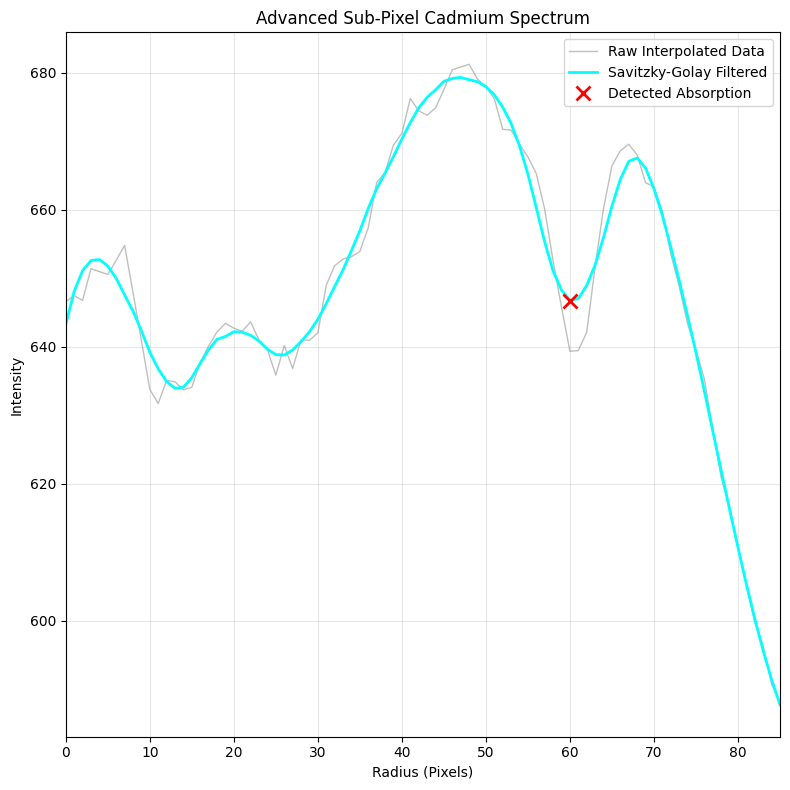

In [79]:
# --- 6. TACTICAL RENDER ---
x_axis = np.arange(len(spectrum_1d))

plt.figure(figsize=(8,8))

# Plot the raw interpolated spectrum faintly in the background
plt.plot(x_axis, spectrum_1d, color='gray', alpha=0.5, linewidth=1, label='Raw Interpolated Data')

# Plot the mathematically ironed spectrum in bold
plt.plot(x_axis, smoothed_spectrum, color='cyan', linewidth=2, label='Savitzky-Golay Filtered')

# Paint the exact valleys with red markers
plt.plot(detected_valleys, valley_intensities, "rx", markersize=10, markeredgewidth=2, label='Detected Absorption')

plt.title("Advanced Sub-Pixel Cadmium Spectrum")
plt.xlabel("Radius (Pixels)")
plt.ylabel("Intensity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, radius_max) # Zoom in to our masked area
plt.tight_layout()
plt.show()

